<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/GitHub_Trending_Repositories_Dataset_(2025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GitHub Trending Repositories Dataset (2025)

#  Dataset Description and Insights



The dataset, `top_owners.csv`, provides a snapshot of the top GitHub repository owners. It contains 100 entries, each representing a unique owner, and four key columns: `owner`, `repo_count`, `total_stars`, and `total_forks`. The `owner` column is categorical, uniquely identifying each entity, while `repo_count`, `total_stars`, and `total_forks` are numerical, representing quantitative aspects of their GitHub presence.

From the initial exploratory data analysis, we can glean several insights:

*   **Data Quality**: The dataset is remarkably clean, with no missing values across any column and no duplicate entries. This suggests that the data is ready for analysis without extensive cleaning.
*   **Distribution Skewness**: The numerical columns—`repo_count`, `total_stars`, and `total_forks`—exhibit a right-skewed distribution. This indicates that while most owners have a moderate number of repositories, stars, and forks, a few prominent owners possess a significantly higher volume in these metrics. For instance, `repo_count` ranges from 1 to 34, `total_stars` from approximately 66,792 to 471,986, and `total_forks` from 2,290 to 132,424. The highest values are significantly greater than their respective means, highlighting a power-law-like distribution common in social and online network data.
*   **Strong Positive Correlations**: A strong positive correlation exists between `repo_count`, `total_stars`, and `total_forks`. This means owners with a higher number of repositories tend to accumulate more stars and forks. Most notably, `total_stars` and `total_forks` are highly correlated, implying that popular repositories (those with many stars) are also frequently forked. This relationship suggests a direct link between a project's popularity and its adoption/contribution by the developer community. The owner 'freeCodeCamp' stands out with the highest total stars, although not the highest repo count, suggesting high impact from fewer repositories.

In summary, this dataset offers valuable insights into the landscape of popular GitHub owners, emphasizing the distribution of their contributions and the strong interdependencies between repository count, stars, and forks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d mihikaajayjadhav/github-trending-repositories-dataset-2025

# Unziping the downloaded file
!unzip github-trending-repositories-dataset-2025.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/mihikaajayjadhav/github-trending-repositories-dataset-2025
License(s): CC0-1.0
  0% 0.00/92.2k [00:00<?, ?B/s]
100% 92.2k/92.2k [00:00<00:00, 329MB/s]
Archive:  github-trending-repositories-dataset-2025.zip
  inflating: github_trending_repos.csv  
  inflating: language_summary.csv    
  inflating: top_owners.csv          


In [3]:
df = pd.read_csv('top_owners.csv')
df.head(11)

,owner,repo_count,total_stars,total_forks
0,freeCodeCamp,2,471986,45203
1,microsoft,14,445001,132424
2,yangshun,3,407415,48873
3,flutter,6,395900,81980
4,netdata,5,384460,31230
5,jackfrued,2,351534,110050
6,iptv-org,3,313224,13983
7,nvm-sh,3,270617,28923
8,apache,19,256921,123651
9,tonsky,3,242016,9522


In [4]:
df.tail(11)

,owner,repo_count,total_stars,total_forks
89,plausible,3,71472,3948
90,localsend,1,71196,3808
91,moby,1,71173,18859
92,jingyaogong,2,70146,8208
93,ocornut,1,69793,11370
94,protocolbuffers,1,69762,15948
95,base,2,69059,3368
96,firecrawl,1,69034,5403
97,apple,9,68251,3936
98,umami-software,2,67842,11972


In [5]:
df.shape

(100, 4)

In [6]:
df.columns

Index(['owner', 'repo_count', 'total_stars', 'total_forks'], dtype='object')

In [7]:
df.dtypes

,0
owner,object
repo_count,int64
total_stars,int64
total_forks,int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   owner        100 non-null    object
 1   repo_count   100 non-null    int64 
 2   total_stars  100 non-null    int64 
 3   total_forks  100 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 3.3+ KB


In [9]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
owner,100,100,freeCodeCamp,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
repo_count,100.0,NaN,NaN,NaN,3.73,4.128871,1.0,2.0,3.0,4.0,34.0
total_stars,100.0,NaN,NaN,NaN,142374.74,85865.498559,66792.0,85279.5,118286.0,163764.0,471986.0
total_forks,100.0,NaN,NaN,NaN,25327.13,28798.539185,2290.0,7562.0,13975.0,29671.75,132424.0


In [10]:
df.isnull().sum()

,0
owner,0
repo_count,0
total_stars,0
total_forks,0


In [11]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

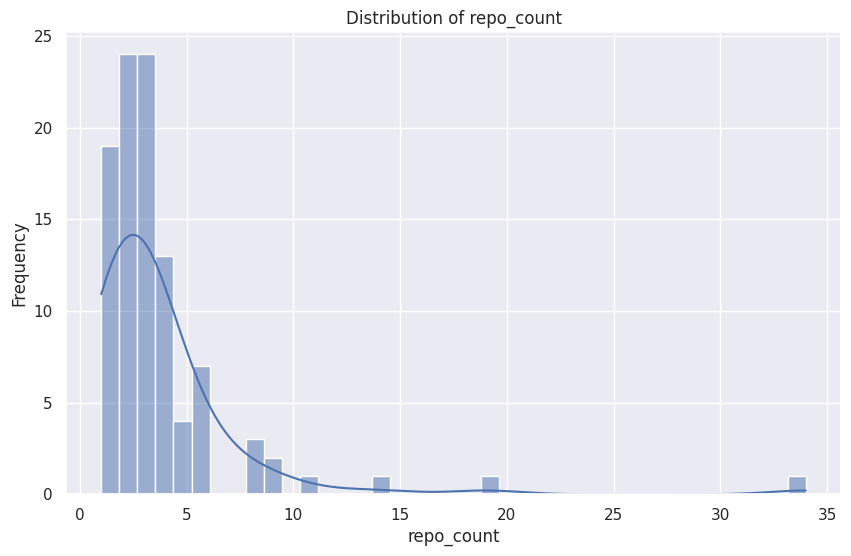

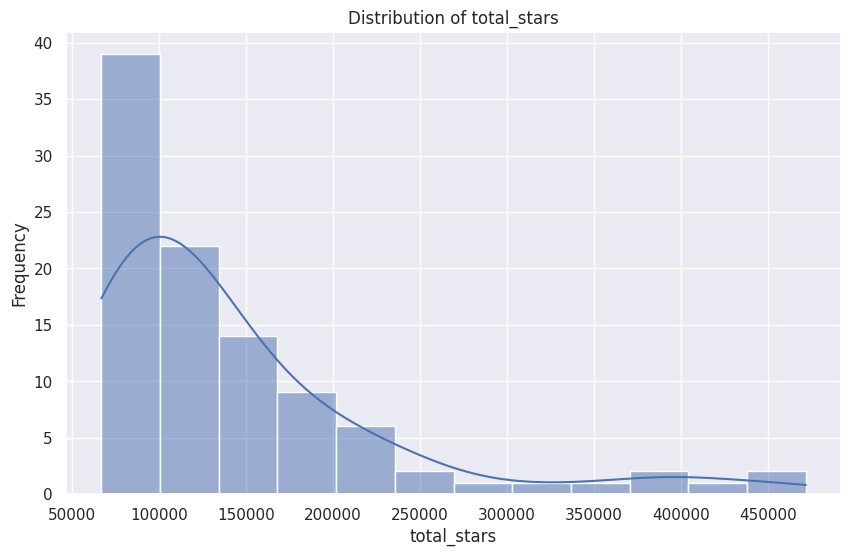

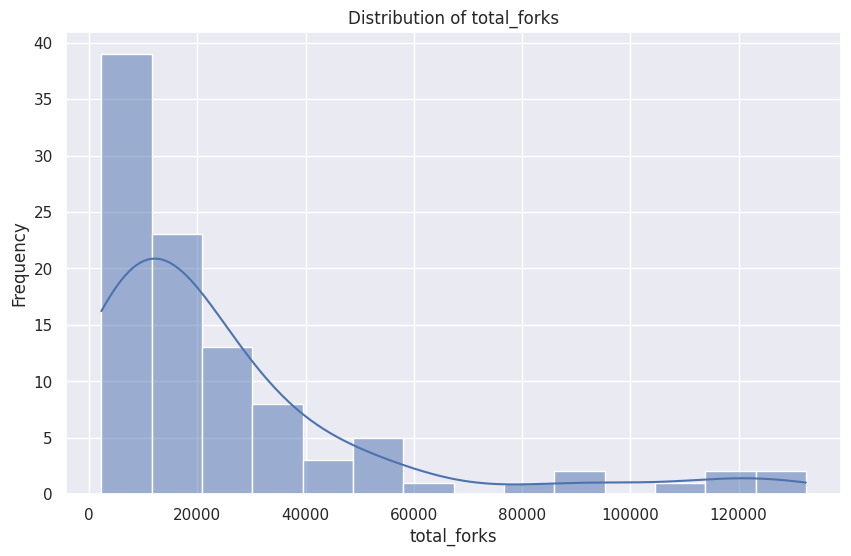

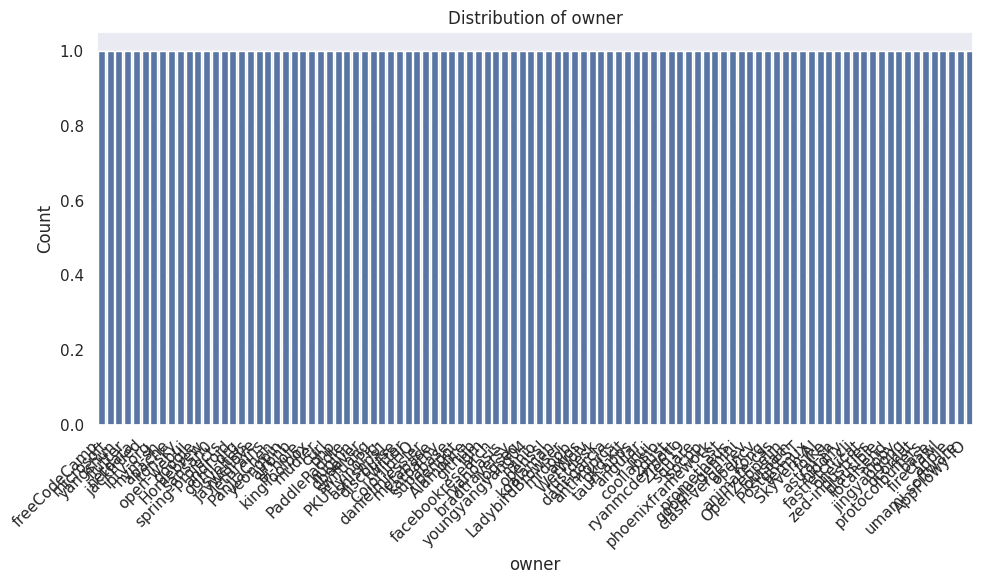

Value counts for owner:
owner
freeCodeCamp      1
microsoft         1
yangshun          1
flutter           1
netdata           1
                 ..
base              1
firecrawl         1
apple             1
umami-software    1
AppFlowy-IO       1
Name: count, Length: 100, dtype: int64



In [12]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterating through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

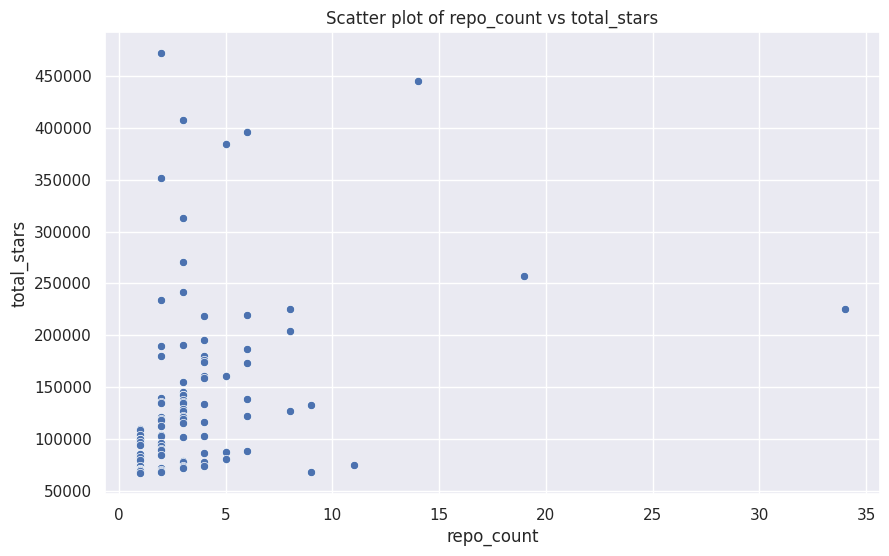

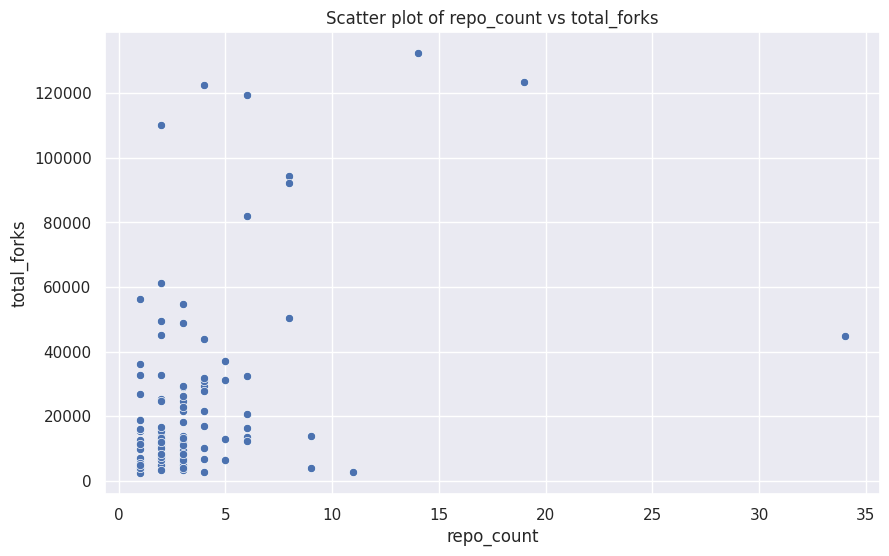

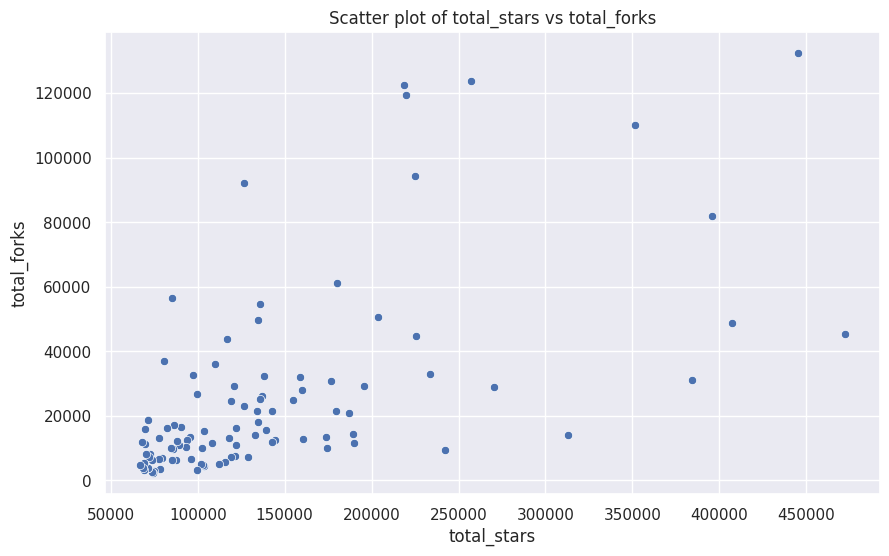

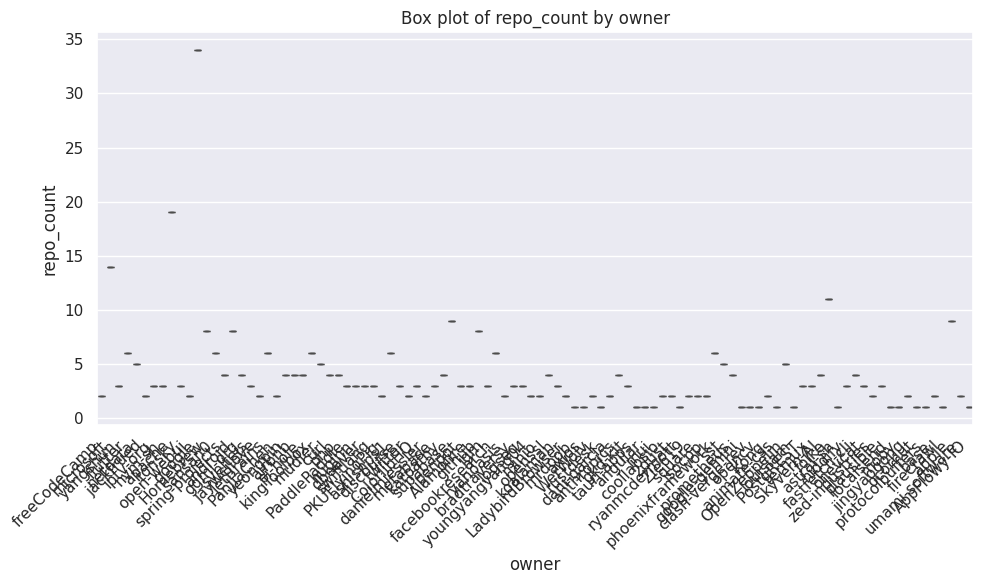

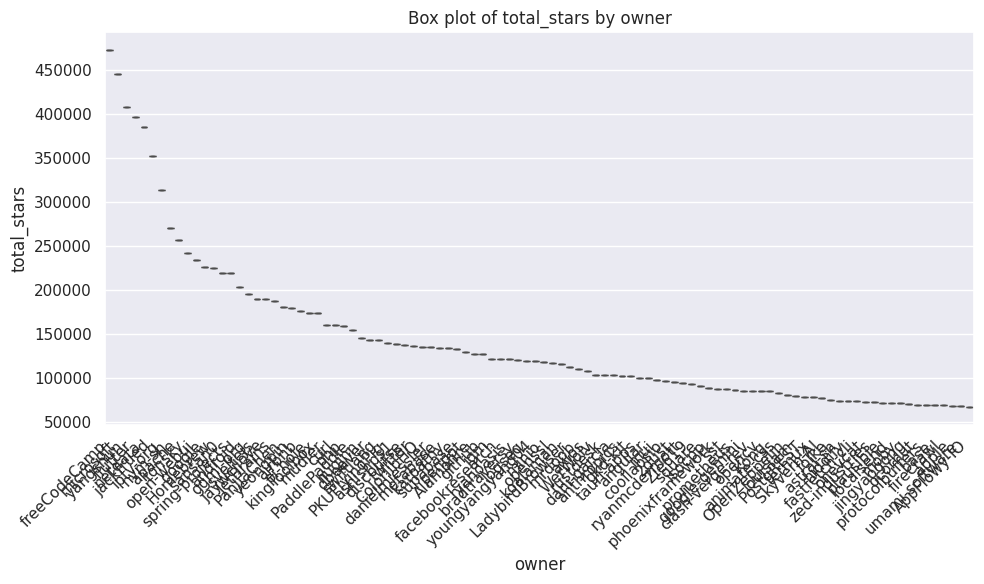

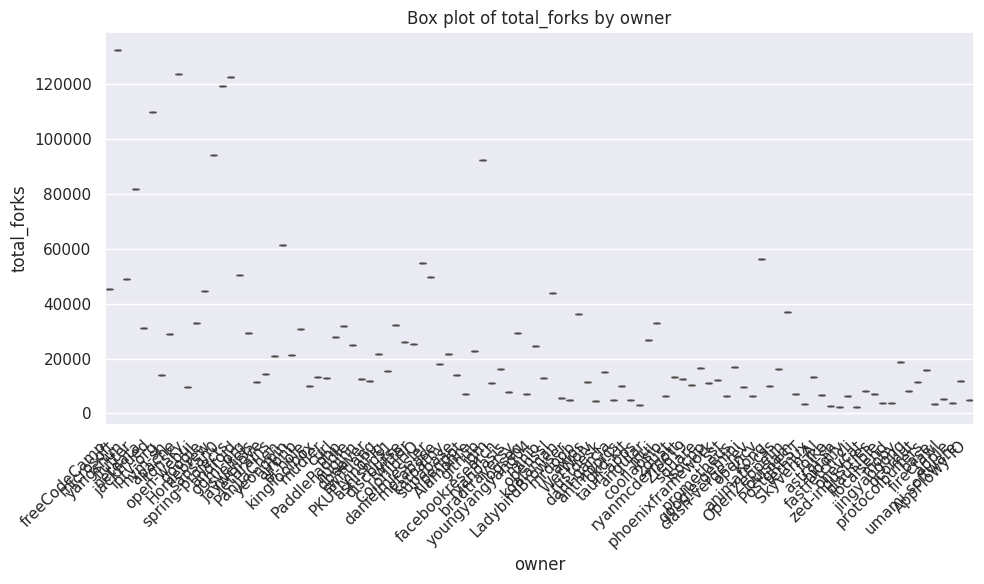

In [13]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude high-cardinality columns that are not suitable for box plots
cols_to_exclude_from_boxplot = ['title', 'original_title', 'overview', 'premiere_date']
filtered_categorical_cols = [col for col in categorical_cols if col not in cols_to_exclude_from_boxplot]

# Iterate through filtered categorical and numerical columns and create box plots
for cat_col in filtered_categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

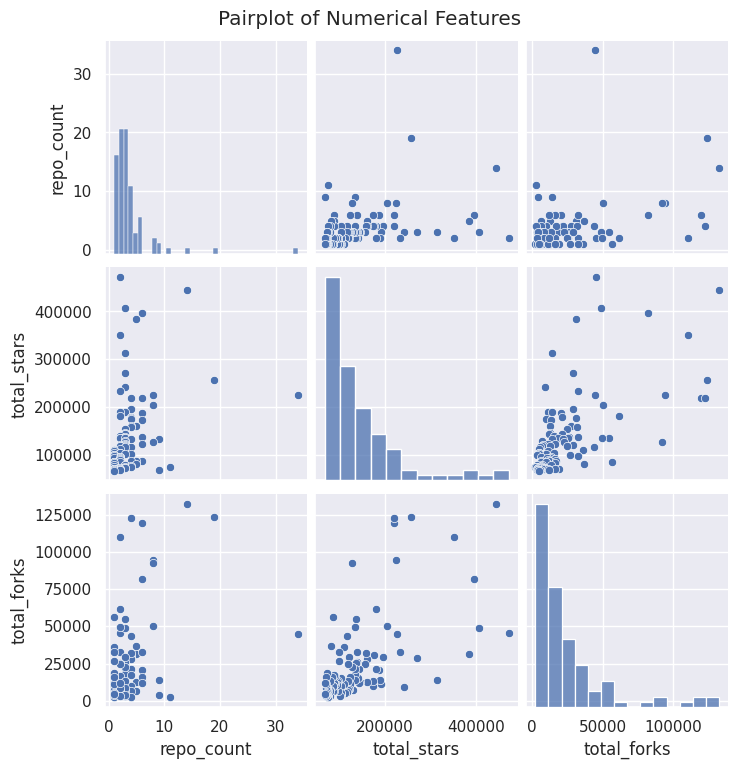

In [14]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

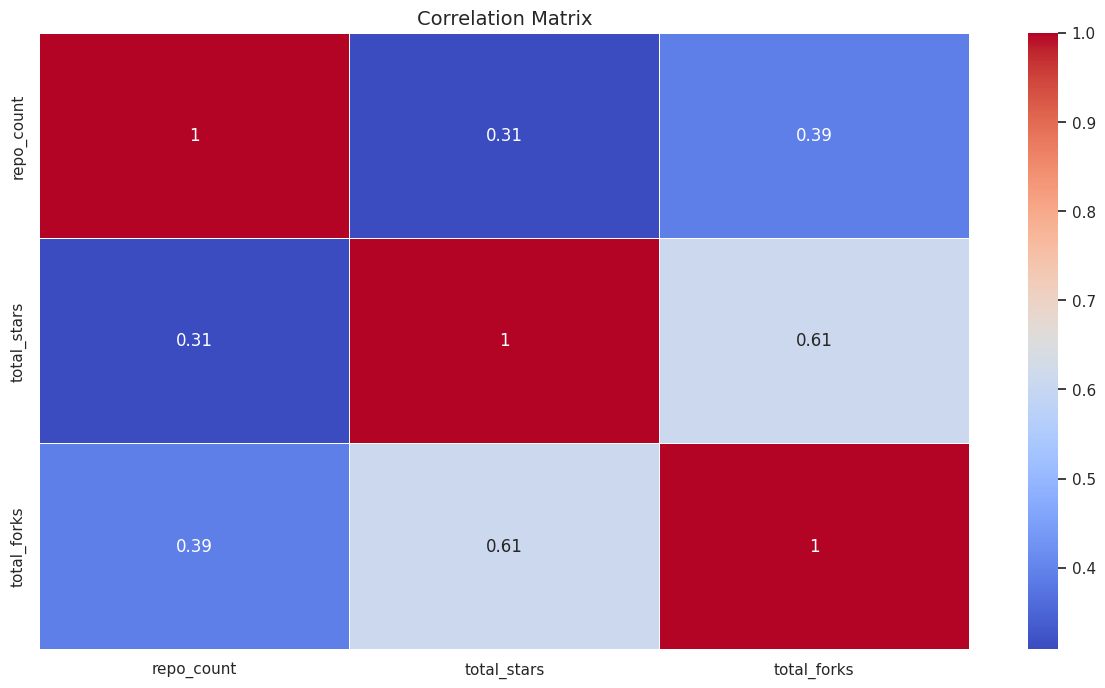

In [15]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You